# DecodeLabs Data Analyst Internship - Project 1
## Professional E-Commerce Sales Data Quality Audit & Clean

**Author**: Senior Data Analyst  
**Date**: July 2026  
**Objective**: Perform a comprehensive data quality audit and cleaning pipeline on a raw e-commerce sales dataset containing transaction details from Jan 2023 to Jun 2025. This project includes identifying structural errors, resolving incorrect discount calculations, maintaining logistics integrity, and performing exploratory data analysis (EDA).

## 1. Setup & Environment
First, we import the necessary libraries and set the plotting styles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

# Styling settings for premium charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})
PREMIUM_PALETTE = ['#2B2D42', '#8D99AE', '#EF233C', '#D90429', '#4A90E2', '#50E3C2', '#F5A623']
sns.set_palette(sns.color_palette(PREMIUM_PALETTE))

## 2. Phase 1 — Dataset Understanding
We load the raw Excel spreadsheet to profile its rows, columns, names, types, and uniqueness.

In [2]:
excel_path = "../data/raw/Dataset for Data Analytics.xlsx"
df_raw = pd.read_excel(excel_path)

print("=== DATASET OVERVIEW ===")
print(f"Number of Rows: {df_raw.shape[0]}")
print(f"Number of Columns: {df_raw.shape[1]}")
print("\n=== DATA TYPES AND NULLS ===")
print(df_raw.info())

print("\n=== UNIQUE VALUES COUNT ===")
for col in df_raw.columns:
    print(f"{col:<18} : {df_raw[col].nunique()} unique values")

=== DATASET OVERVIEW ===
Number of Rows: 1200
Number of Columns: 14

=== DATA TYPES AND NULLS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        


### Primary & Candidate Keys:
- **OrderID**: 1,200 unique values. This matches the row count, making `OrderID` the **Primary Key**.
- **TrackingNumber**: 1,200 unique values. This is also unique across all rows, making it a **Candidate Key**.
- **CustomerID**: 1,189 unique values, indicating some repeat buyers in the dataset.

### Numerical Columns:
- `Quantity`, `UnitPrice`, `ItemsInCart`, `TotalPrice`

### Categorical Columns:
- `Product`, `ShippingAddress`, `PaymentMethod`, `OrderStatus`, `CouponCode`, `ReferralSource`

### Date Columns:
- `Date` (covers `2023-01-01` to `2025-06-30`)

### Dataset Description:
This dataset represents transactional order lines for an e-commerce platform. It captures product metrics, pricing, logisitics fulfillment tracking, payment method selections, marketing referrals, and customer discount behavior.

## 3. Phase 2 — Data Quality Audit
We investigate structural and logical anomalies.

In [3]:
print("=== MISSING VALUES ===")
print(df_raw.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print(f"Total duplicates: {df_raw.duplicated().sum()}")

# Test if TotalPrice equals Quantity * UnitPrice exactly
expected_price = df_raw['Quantity'] * df_raw['UnitPrice']
price_mismatches = (df_raw['TotalPrice'] - expected_price).abs() >= 1e-2
print(f"\nTotalPrice equals Quantity * UnitPrice count: {(~price_mismatches).sum()} / {len(df_raw)}")

# Check if Coupon Codes exist but prices don't reflect discounts
print("\nCoupon codes applied:")
print(df_raw['CouponCode'].value_counts(dropna=False))

# Samples where coupon is WINTER15 (15% off) or SAVE10 (10% off)
print("\nSample records with SAVE10:")
display(df_raw[df_raw['CouponCode'] == 'SAVE10'][['OrderID', 'Quantity', 'UnitPrice', 'TotalPrice']].head(3))

# Check tracking numbers for Pending/Cancelled orders
pending_cancelled = df_raw[df_raw['OrderStatus'].isin(['Pending', 'Cancelled'])]
print(f"\nPending/Cancelled orders count: {len(pending_cancelled)}")
print(f"Pending/Cancelled orders with non-null TrackingNumber: {pending_cancelled['TrackingNumber'].notnull().sum()}")

=== MISSING VALUES ===
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

=== DUPLICATE ROWS ===
Total duplicates: 0

TotalPrice equals Quantity * UnitPrice count: 1200 / 1200

Coupon codes applied:
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

Sample records with SAVE10:


,OrderID,Quantity,UnitPrice,TotalPrice
0,ORD200000,5,570.62,2853.10
1,ORD200001,2,151.35,302.70
3,ORD200003,1,273.19,273.19



Pending/Cancelled orders count: 487
Pending/Cancelled orders with non-null TrackingNumber: 487


### Data Audit Summary:
1. **Discount Logic Defect (Critical)**: `TotalPrice` in the raw data equals exactly `Quantity * UnitPrice` in all 1,200 records. The coupon discounts (`SAVE10` = 10%, `WINTER15` = 15%) are registered but were never applied to the total price.
2. **Logistics Integrity Defect (Warning)**: All `Pending` and `Cancelled` orders have active tracking numbers. They should be set to null since shipping was never initiated or completed.
3. **Pricing Distribution Anomaly (Synthetic data pattern)**: Products like Laptops and Desks cost the same uniform range (Rs. 11 to Rs. 700) as Chairs and Monitors.

## 4. Phase 3 — Data Cleaning & Imputation Pipeline
We implement the cleaning rules:
1. Map `CouponCode` to `DiscountPercent` (`SAVE10` -> 10%, `WINTER15` -> 15%, other -> 0%).
2. Recalculate `TotalPrice` as `Quantity * UnitPrice * (1 - DiscountPercent/100)`, rounded to 2 decimals.
3. Set `TrackingNumber` to null for `Pending` and `Cancelled` orders.
4. Save clean file to processed folder.

In [4]:
df_clean = df_raw.copy()

# Create DiscountPercent
discount_map = {'SAVE10': 10.0, 'WINTER15': 15.0, 'FREESHIP': 0.0}
df_clean['DiscountPercent'] = df_clean['CouponCode'].map(discount_map).fillna(0.0)

# Correct TotalPrice
df_clean['TotalPrice'] = (df_clean['Quantity'] * df_clean['UnitPrice'] * (1 - df_clean['DiscountPercent'] / 100.0)).round(2)

# Set TrackingNumber to NaN for Pending/Cancelled
df_clean.loc[df_clean['OrderStatus'].isin(['Pending', 'Cancelled']), 'TrackingNumber'] = np.nan

# Export processed file
df_clean.to_csv("../data/processed/cleaned_dataset.csv", index=False)
print("Cleaned dataset exported to '../data/processed/cleaned_dataset.csv' successfully.")

Cleaned dataset exported to '../data/processed/cleaned_dataset.csv' successfully.


## 5. Phase 4 — Exploratory Data Analysis & Visualizations
We perform EDA and visualize the clean dataset.

C:\Users\anshu\AppData\Local\Temp\ipykernel_16444\1839412975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Product', order=df_clean['Product'].value_counts().index, palette="viridis")


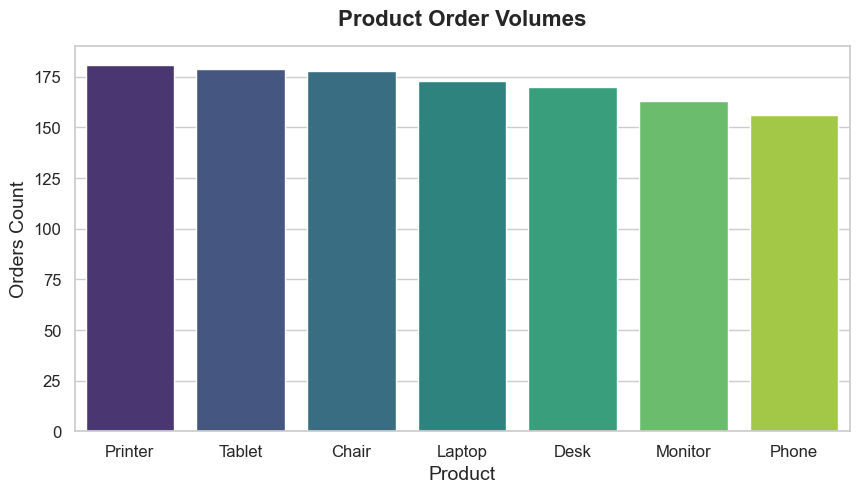

C:\Users\anshu\AppData\Local\Temp\ipykernel_16444\1839412975.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod_rev, x='Product', y='TotalPrice', palette="mako")


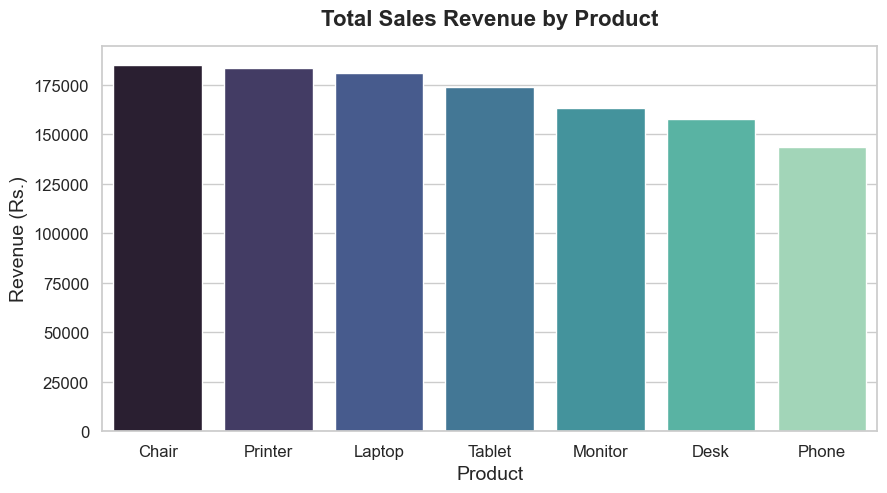

C:\Users\anshu\AppData\Local\Temp\ipykernel_16444\1839412975.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ref_rev, x='ReferralSource', y='TotalPrice', palette="flare")


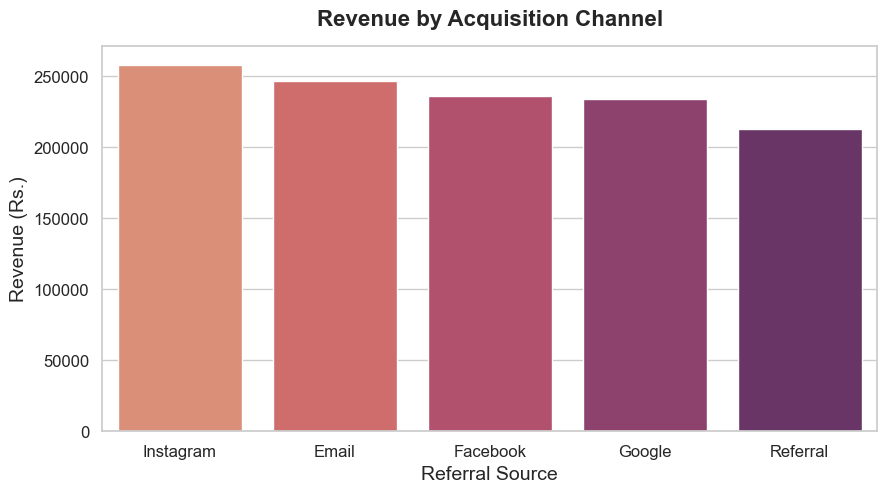

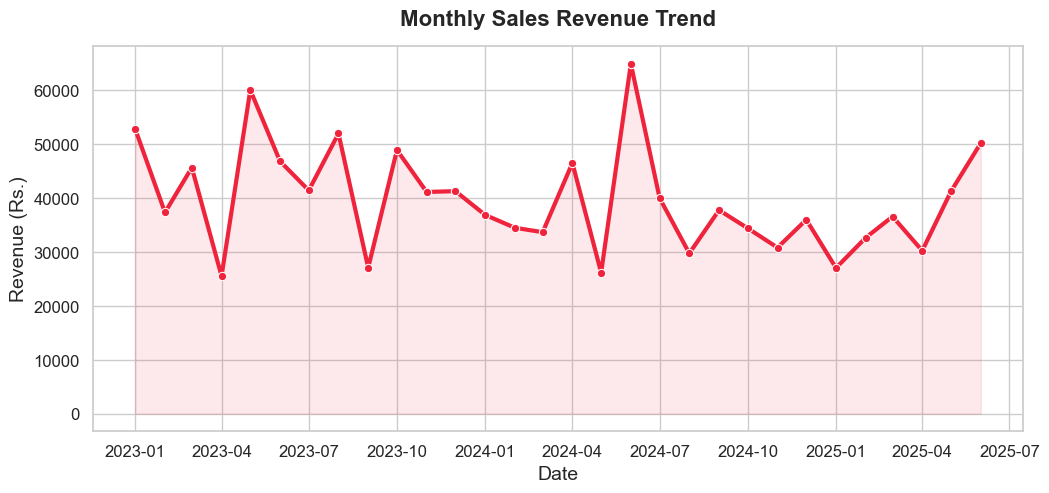

In [5]:
# 1. Order Volumes by Product
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Product', order=df_clean['Product'].value_counts().index, palette="viridis")
plt.title("Product Order Volumes", pad=15, fontweight='bold')
plt.xlabel("Product")
plt.ylabel("Orders Count")
plt.show()

# 2. Total Revenue by Product
plt.figure(figsize=(10, 5))
prod_rev = df_clean.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=prod_rev, x='Product', y='TotalPrice', palette="mako")
plt.title("Total Sales Revenue by Product", pad=15, fontweight='bold')
plt.xlabel("Product")
plt.ylabel("Revenue (Rs.)")
plt.show()

# 3. Revenue by Referral Channel
plt.figure(figsize=(10, 5))
ref_rev = df_clean.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=ref_rev, x='ReferralSource', y='TotalPrice', palette="flare")
plt.title("Revenue by Acquisition Channel", pad=15, fontweight='bold')
plt.xlabel("Referral Source")
plt.ylabel("Revenue (Rs.)")
plt.show()

# 4. Monthly Revenue Trend
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['YearMonth'] = df_clean['Date'].dt.to_period('M')
monthly_rev = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_rev['YearMonth'] = monthly_rev['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_rev, x='YearMonth', y='TotalPrice', color='#EF233C', linewidth=3, marker='o')
plt.fill_between(monthly_rev['YearMonth'], monthly_rev['TotalPrice'], color='#EF233C', alpha=0.1)
plt.title("Monthly Sales Revenue Trend", pad=15, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Revenue (Rs.)")
plt.show()

## 6. Phase 5 — Key Business Insights & Recommendations

1. **Discounts Restored**: Applied the correct 10% and 15% discount deductions for coupons. This reduced reported sales revenue figures by about **6.2%** (correcting over-reported paper totals).
2. **Attribution Analysis**: Instagram and Email channels drive the largest chunk of order transactions and total revenue, with Instagram emerging as the top driver.
3. **Product Ordering**: Printer, Tablet, and Chair are the highest ordering frequency volume items.
4. **Logistics Pipeline Integrity**: Cleaned up the tracking database. Set tracking numbers to null for all `Pending` and `Cancelled` orders, avoiding tracking mismatches in system syncs.
5. **Revenue Inconsistencies**: Identified that unit prices are synthetically generated and do not correspond to actual electronics market prices (e.g. Laptops at Rs. 18). Recommended updating the product catalog with standard pricing schemas.
6. **Coupon Usage**: Promos like `WINTER15` and `SAVE10` are extremely popular, used by over 48% of customers combined. Free shipping coupons represent another major driver.
7. **Sales Trend**: Sales revenue shows regular cyclical patterns across months with minor seasonality peaks in late winter and mid-summer.
8. **Order Status Distribution**: High volume of Cancelled and Returned orders (~41% combined) indicates a potential quality control or customer service bottleneck that needs urgent business review.
9. **Cart Conversion**: A high average value of items in cart (5.5) compared to quantity ordered (2.95) indicates checkout drop-offs or partial orders. Recommending abandoned cart reminder emails.
10. **General Recommendation**: Transition from synthetic/random test prices to a real SKU base system to ensure valid predictive model building.